# Succinct RINEX Compression Analysis

Exploratory analysis of RINEX observation data to inform the design of
a "succinct RINEX" (SRNX) compression format. Key questions:

1. What delta orders minimize bit-widths for different observable types?
2. How often do bit-widths remain stable across consecutive deltas?
3. What are natural block sizes for bit-transposed storage?

In [1]:
import os
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from librinex import RinexFile

# Load a RINEX file -- adjust path as needed
f = RinexFile('../2020_200/mtsy2000.20o')
print(f'RINEX version: {f.rinex_version}')
print(f'Epochs: {f.n_epochs}')
print(f'Interval: {f.interval}s')

RINEX version: 2
Epochs: 86400
Interval: 1s


In [2]:
# List constellations, satellites, and observables
for sys_char in 'GREJCSI':
    codes = f.obs_codes(sys_char)
    if not codes:
        continue
    sats = f.satellites(sys_char)
    print(f'{sys_char}: {len(sats)} satellites, {len(codes)} observables: {codes}')
    print(f'   Satellites: {sats}')

G: 32 satellites, 17 observables: ['C1', 'L1', 'S1', 'P1', 'C2', 'L2', 'S2', 'P2', 'C5', 'L5', 'S5', 'C7', 'L7', 'S7', 'C8', 'L8', 'S8']
   Satellites: ['G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10', 'G11', 'G12', 'G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29', 'G30', 'G31', 'G32']
R: 23 satellites, 17 observables: ['C1', 'L1', 'S1', 'P1', 'C2', 'L2', 'S2', 'P2', 'C5', 'L5', 'S5', 'C7', 'L7', 'S7', 'C8', 'L8', 'S8']
   Satellites: ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15', 'R16', 'R17', 'R18', 'R19', 'R20', 'R21', 'R23', 'R24']
E: 22 satellites, 17 observables: ['C1', 'L1', 'S1', 'P1', 'C2', 'L2', 'S2', 'P2', 'C5', 'L5', 'S5', 'C7', 'L7', 'S7', 'C8', 'L8', 'S8']
   Satellites: ['E01', 'E02', 'E03', 'E04', 'E05', 'E07', 'E08', 'E09', 'E11', 'E12', 'E13', 'E15', 'E19', 'E21', 'E24', 'E25', 'E26', 'E27', 'E30', 'E31', 'E33', 'E36']
S:

## GCD Reduction

Many RINEX observations are exact multiples of 10, 250, etc. Dividing
by the per-observable GCD before any analysis reduces bit-widths for free.

In [3]:
from math import gcd
from functools import reduce
import statistics

MISSING = np.iinfo(np.int64).min

# Compute GCD per (satellite, observable) pair, matching SRNX per-SOCD encoding
SYS = 'G'
sats = f.satellites(SYS)
codes = f.obs_codes(SYS)

obs_gcd = {}
for sat in sats:
    for idx, code in enumerate(codes):
        obs = f.get_obs(sat, idx)
        valid = np.abs(obs[obs != MISSING]).astype(int)
        g = int(reduce(gcd, valid)) if len(valid) > 0 else 1
        g = g if 0 < g <= 1_000_000 else 1
        obs_gcd[(sat, idx)] = g

# Summarize per observable code: min/median/max GCD across satellites
print(f'{"Code":>4} {"Min GCD":>10} {"Med GCD":>10} {"Max GCD":>10}')
print('-' * 38)
for idx, code in enumerate(codes):
    gcds = [obs_gcd[(sat, idx)] for sat in sats]
    print(f'{code:>4} {min(gcds):>10} {int(statistics.median(gcds)):>10} {max(gcds):>10}')

def get_obs_reduced(sat, idx):
    """Return observations for (sat, idx) divided by the per-SOCD GCD."""
    obs = f.get_obs(sat, idx)
    g = obs_gcd.get((sat, idx), 1)
    if g > 1:
        out = obs.copy()
        valid = out != MISSING
        out[valid] //= g
        return out
    return obs

Code    Min GCD    Med GCD    Max GCD
--------------------------------------
  C1          1          1          1
  L1          1          1          1
  S1        100        100        100
  P1          1          1          1
  C2          1          1          1
  L2          1          1          1
  S2        100        100        100
  P2          1          1          1
  C5          1          1          1
  L5          1          1          1
  S5          1          1        100
  C7          1          1          1
  L7          1          1          1
  S7          1          1          1
  C8          1          1          1
  L8          1          1          1
  S8          1          1          1


## Raw Observation Time Series

Using satellite G01, observables: ['C1', 'L1', 'S1', 'P1', 'C2', 'L2', 'S2', 'P2', 'C5', 'L5', 'S5', 'C7', 'L7', 'S7', 'C8', 'L8', 'S8']


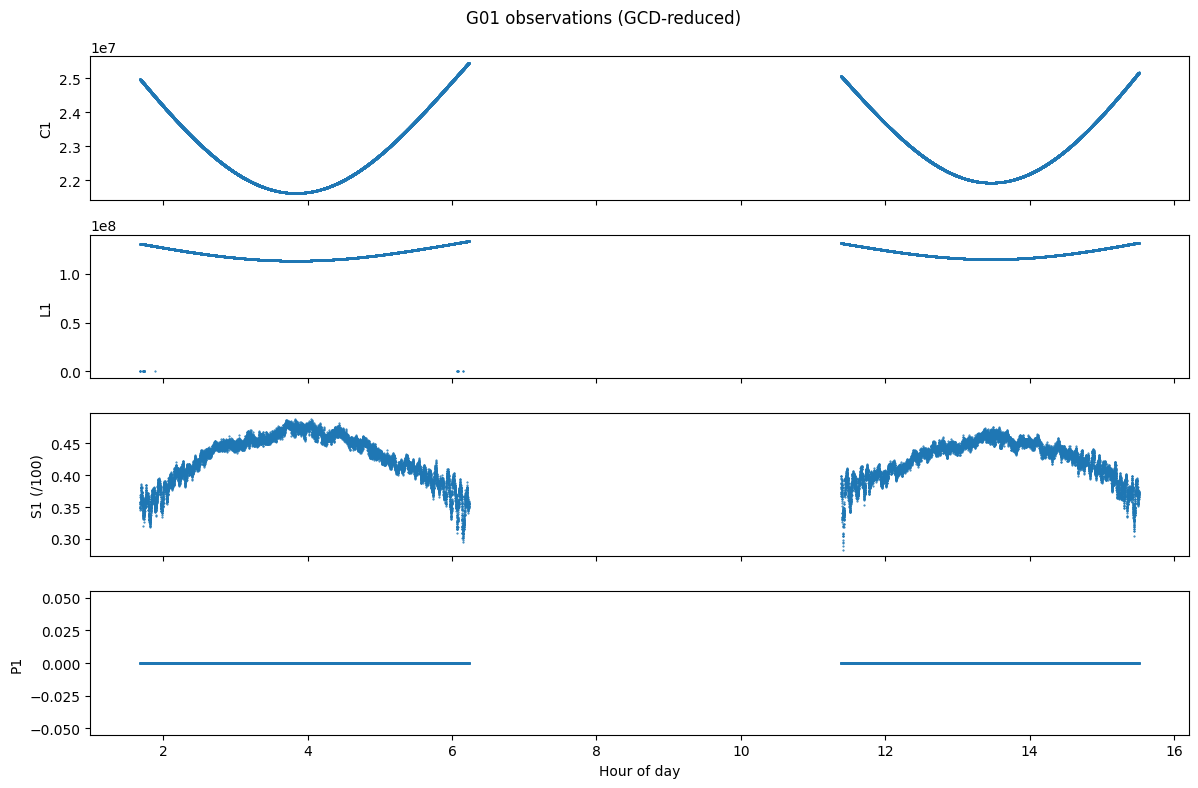

In [4]:
# Pick a satellite and observable to examine
sat = sats[0] if sats else None
print(f'Using satellite {sat}, observables: {codes}')

sod = f.get_epochs_sod()
hours = sod / 3600.0

# Plot a few observables for this satellite (GCD-reduced)
fig, axes = plt.subplots(min(4, len(codes)), 1, figsize=(12, 8), sharex=True)
if not hasattr(axes, '__len__'):
    axes = [axes]
for ax, (idx, code) in zip(axes, enumerate(codes[:4])):
    obs = get_obs_reduced(sat, idx)
    valid = obs != MISSING
    masked = np.where(valid, obs / 1000.0, np.nan)
    ax.plot(hours, masked, '.', markersize=1)
    g = obs_gcd.get((sat, idx), 1)
    label = f'{code} (/{g})' if g > 1 else code
    ax.set_ylabel(label)
axes[-1].set_xlabel('Hour of day')
fig.suptitle(f'{sat} observations (GCD-reduced)')
plt.tight_layout()

## Delta Chain Computation

Compute differences of orders 0 through 5, like CRX differential compression.

In [5]:
def delta_chain(obs_raw, max_order=5):
    """Compute deltas of orders 0..max_order on non-missing values.
    Returns list of arrays, one per order."""
    valid = obs_raw != MISSING
    vals = obs_raw[valid].astype(np.int64)
    chain = [vals.copy()]
    for _ in range(max_order):
        if len(vals) < 2:
            break
        vals = np.diff(vals)
        chain.append(vals.copy())
    return chain

def bit_widths(values):
    """Compute signed bit-width of each value (zigzag encoding)."""
    zigzag = np.where(values >= 0, values * 2, -values * 2 - 1).astype(np.uint64)
    bw = np.zeros(len(zigzag), dtype=np.int32)
    nonzero = zigzag > 0
    bw[nonzero] = np.floor(np.log2(zigzag[nonzero].astype(np.float64))).astype(np.int32) + 1
    return bw

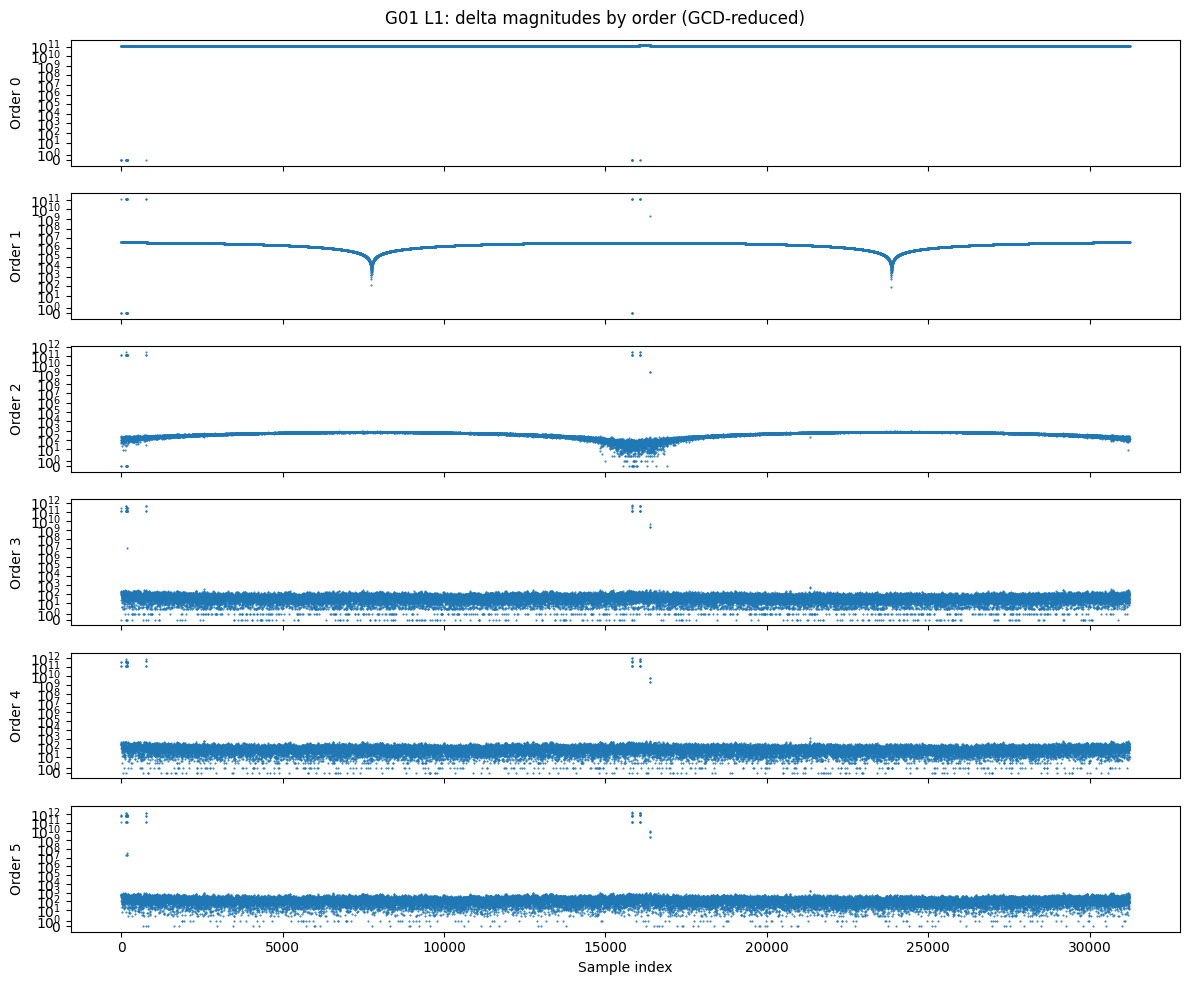

In [6]:
# Show delta magnitudes at each order for a carrier phase observable
# Find first L-type observable
l_idx = next((i for i, c in enumerate(codes) if c.startswith('L')), 0)
obs_raw = get_obs_reduced(sat, l_idx)
chain = delta_chain(obs_raw)

fig, axes = plt.subplots(len(chain), 1, figsize=(12, 10), sharex=True)
for order, (ax, vals) in enumerate(zip(axes, chain)):
    ax.plot(np.abs(vals.astype(np.float64)), '.', markersize=1)
    ax.set_ylabel(f'Order {order}')
    ax.set_yscale('symlog')
axes[-1].set_xlabel('Sample index')
fig.suptitle(f'{sat} {codes[l_idx]}: delta magnitudes by order (GCD-reduced)')
plt.tight_layout()

## Bit-Width Distributions

For each observable type (C=pseudorange, L=carrier phase, D=Doppler, S=SNR),
show histogram of bit-widths at each delta order.

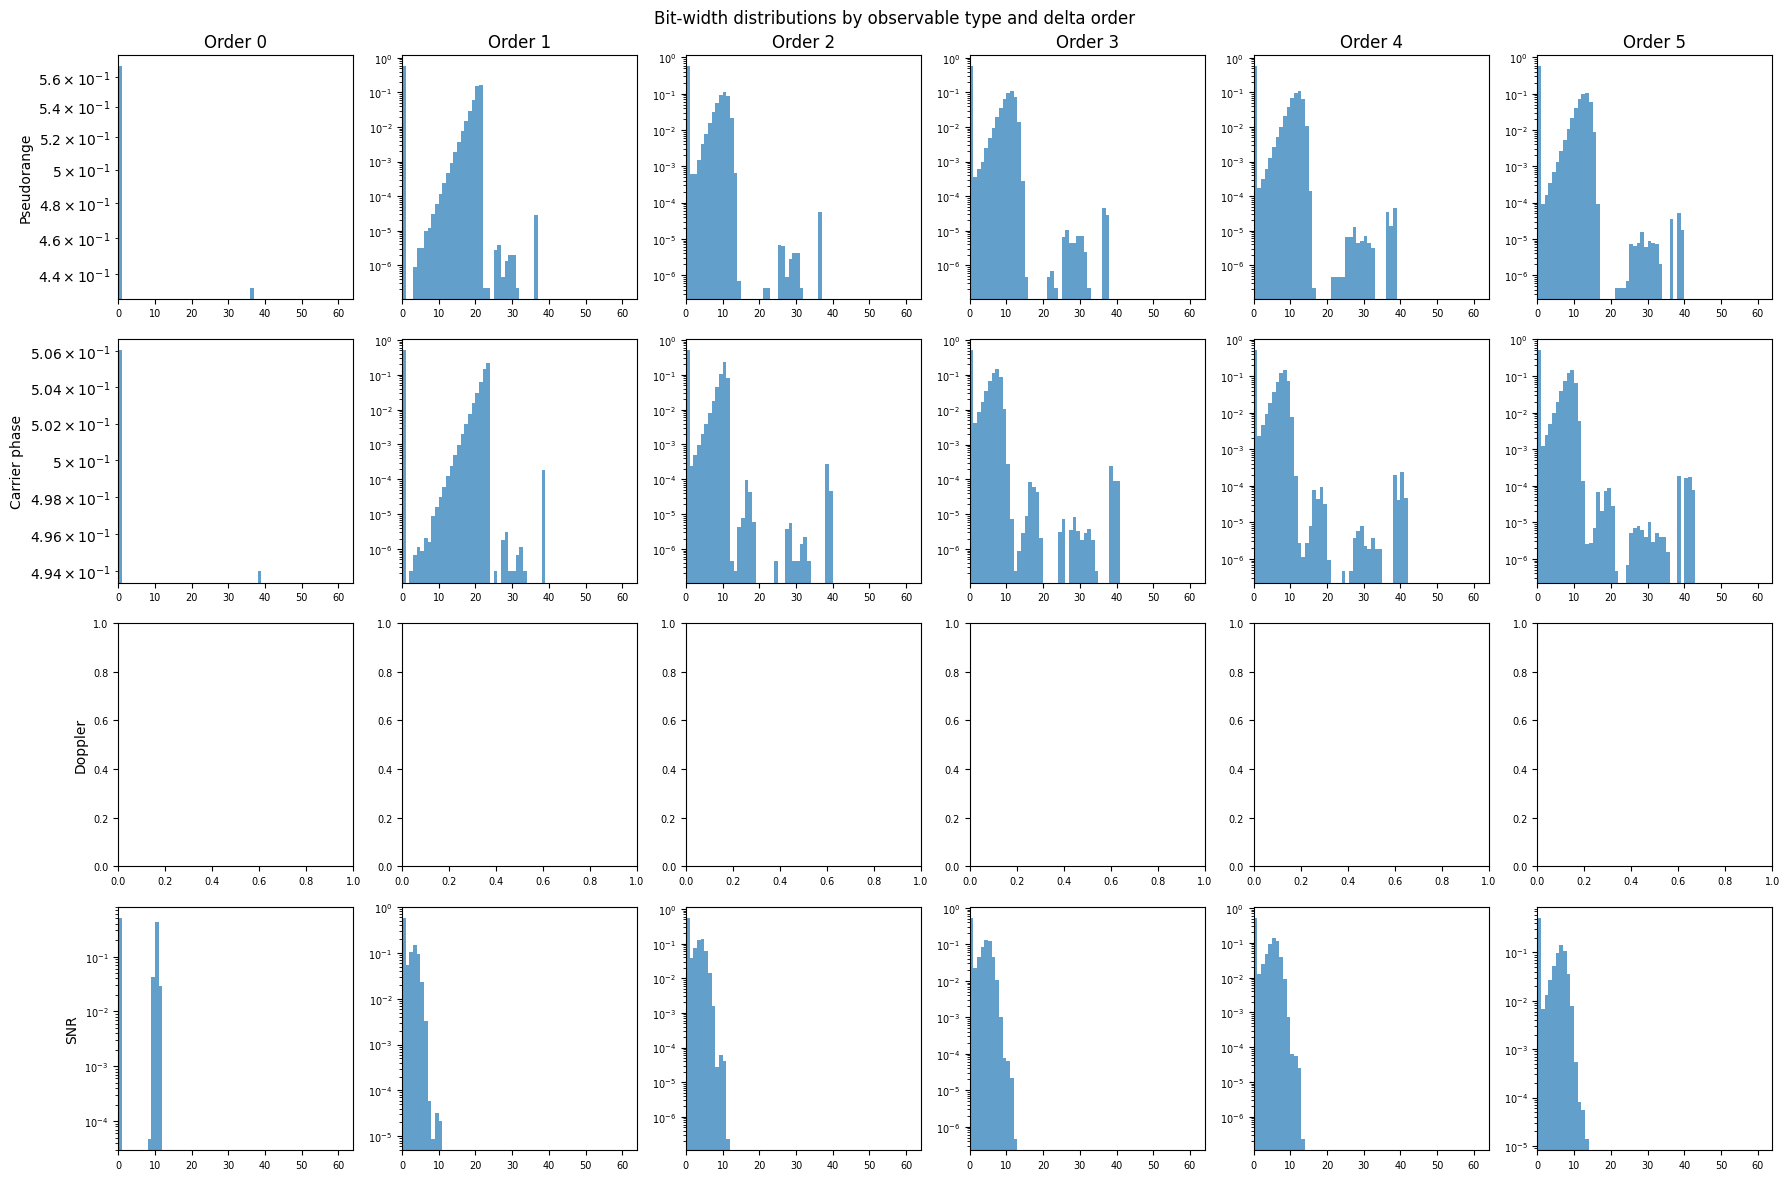

In [7]:
obs_types = {'C': 'Pseudorange', 'L': 'Carrier phase', 'D': 'Doppler', 'S': 'SNR'}

# Collect bit-widths across all satellites for each obs type and delta order
bw_by_type = {t: [[] for _ in range(6)] for t in obs_types}

for sat in f.satellites(SYS):
    for idx, code in enumerate(codes):
        obs_type = code[0]
        if obs_type not in obs_types:
            continue
        obs_raw = get_obs_reduced(sat, idx)
        chain = delta_chain(obs_raw)
        for order, vals in enumerate(chain):
            if len(vals) > 0:
                bw = bit_widths(vals)
                bw_by_type[obs_type][order].append(bw)

# Plot histograms
fig, axes = plt.subplots(len(obs_types), 6, figsize=(18, 12))
for row, (otype, label) in enumerate(obs_types.items()):
    for order in range(6):
        ax = axes[row, order]
        all_bw = bw_by_type[otype][order]
        if all_bw:
            combined = np.concatenate(all_bw)
            ax.hist(combined, bins=range(0, 65), density=True, alpha=0.7)
            ax.set_xlim(0, 64)
            ax.set_yscale('log')
        if row == 0:
            ax.set_title(f'Order {order}')
        if order == 0:
            ax.set_ylabel(label)
        ax.tick_params(labelsize=7)

fig.suptitle('Bit-width distributions by observable type and delta order')
plt.tight_layout()

## Run-Length Analysis

For each block size (16, 32, 64, 128), slide a window across the bit-width
sequence and record the maximum bit-width in each block. The histogram shows
how often a new block of that size requires a given bit-width — i.e., how
wide the bit-matrix rows need to be for that block.

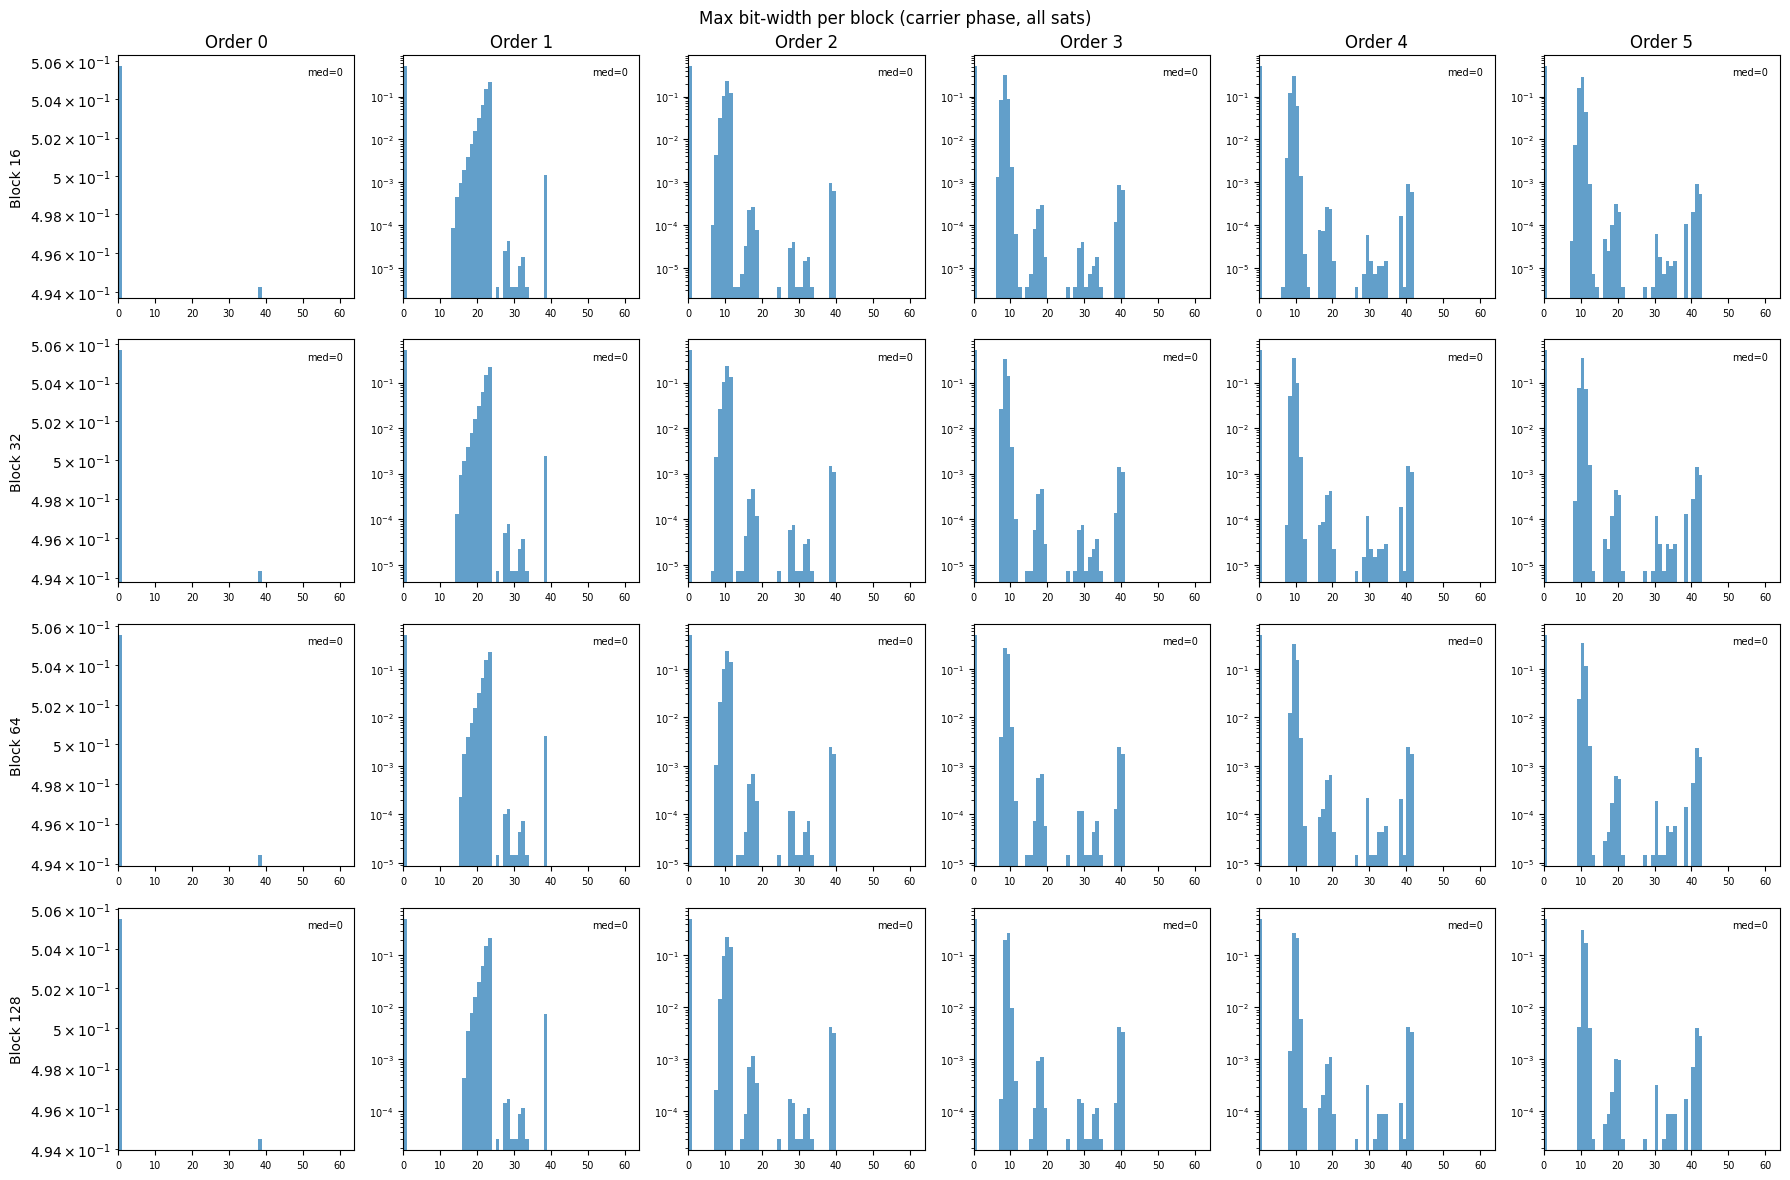

In [8]:
block_sizes = [16, 32, 64, 128]

def block_max_bw(bw_array, block_size):
    """For each non-overlapping block, return the max bit-width."""
    n = len(bw_array)
    n_blocks = n // block_size
    if n_blocks == 0:
        return np.array([], dtype=np.int32)
    trimmed = bw_array[:n_blocks * block_size].reshape(n_blocks, block_size)
    return trimmed.max(axis=1)

# Collect block-max bit-widths for carrier phase at each delta order and block size
fig, axes = plt.subplots(len(block_sizes), 6, figsize=(18, 12))
for col, order in enumerate(range(6)):
    for row, bs in enumerate(block_sizes):
        ax = axes[row, col]
        all_block_bw = []
        for sat in f.satellites(SYS):
            for idx, code in enumerate(codes):
                if not code.startswith('L'):
                    continue
                obs_raw = get_obs_reduced(sat, idx)
                chain = delta_chain(obs_raw, max_order=order)
                if len(chain) > order and len(chain[order]) > 0:
                    bw = bit_widths(chain[order])
                    mbw = block_max_bw(bw, bs)
                    if len(mbw) > 0:
                        all_block_bw.append(mbw)

        if all_block_bw:
            combined = np.concatenate(all_block_bw)
            ax.hist(combined, bins=range(0, 65), density=True, alpha=0.7)
            ax.set_xlim(0, 64)
            ax.set_yscale('log')
            median_bw = np.median(combined)
            if row == 0:
                ax.set_title(f'Order {order}')
            ax.text(0.95, 0.95, f'med={median_bw:.0f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=7)
        if col == 0:
            ax.set_ylabel(f'Block {bs}')
        ax.tick_params(labelsize=7)

fig.suptitle('Max bit-width per block (carrier phase, all sats)')
plt.tight_layout()

<cell_type>markdown</cell_type>## Compression Ratio Estimates

For each satellite/observable, estimate bytes needed under different schemes:
- Raw (original int64 values)
- Best delta order + variable-length encoding
- Bit-matrix packing with fixed block size (32)
- Bit-matrix packing with variable block size (greedy: 16/32/64/128),
  1-byte header per block (6-bit width + 2-bit block-size selector)
- Two-level bit-matrix: base layer at a chosen width B, overflow mask (1 bit
  per value), and overflow bit-matrix for outliers; 2-byte header per block
- Coding lower bound: entropy of bit-width sequence + mantissa bits
  (leading 1 implicit per value)

In [9]:
BLOCK_SIZES = np.array([16, 32, 64, 128])

def varint_bytes(bw_array):
    """Estimate total bytes for signed LEB128 encoding."""
    return int(np.sum(np.maximum(np.ceil((bw_array + 1) / 7.0), 1)))

def bitmatrix_fixed_bytes(bw_array, block_size=32):
    """Estimate bytes for bit-matrix packing with a fixed block size."""
    n = len(bw_array)
    total_bits = 0
    for start in range(0, n, block_size):
        end = min(start + block_size, n)
        block_bw = bw_array[start:end]
        max_bw = int(np.max(block_bw)) if len(block_bw) > 0 else 0
        total_bits += 8 + max_bw * (end - start)
    return (total_bits + 7) // 8

def bitmatrix_var_bytes(bw_array):
    """Estimate bytes for bit-matrix packing with variable block sizes.

    Greedy: at each position, pick the block size (16/32/64/128) that
    minimizes bits per value (header amortized over block).  Each block
    costs 1 header byte (6-bit width capped at 63, 2-bit block-size
    selector) plus width * block_size payload bits.
    """
    n = len(bw_array)
    total_bits = 0
    pos = 0
    bw = bw_array.astype(np.int32)
    while pos < n:
        best_rate = None
        best_cost = 0
        best_bs = 16
        for bs in BLOCK_SIZES:
            end = min(pos + bs, n)
            actual = end - pos
            if actual < bs and actual < 16:
                continue
            max_bw = int(np.max(bw[pos:end]))
            if max_bw > 63:
                max_bw = 63
            cost = 8 + max_bw * actual
            rate = cost / actual
            if best_rate is None or rate < best_rate:
                best_rate = rate
                best_cost = cost
                best_bs = actual if actual < 16 else bs
        total_bits += best_cost
        pos += best_bs
    return (total_bits + 7) // 8

def bitmatrix_split_bytes(bw_array):
    """Estimate bytes for two-level (base + overflow) bit-matrix.

    For each block, choose a base width B that minimizes total cost:
      2-byte header + B*N base bits + N mask bits + overflow_max*(count of bw>B) bits
    Also considers the single-level encoding (1-byte header, no mask)
    and picks whichever is cheaper.
    """
    n = len(bw_array)
    total_bits = 0
    pos = 0
    bw = bw_array.astype(np.int32)
    while pos < n:
        best_rate = None
        best_cost = 0
        best_bs = 16
        for bs in BLOCK_SIZES:
            end = min(pos + bs, n)
            actual = end - pos
            if actual < bs and actual < 16:
                continue
            block_bw = bw[pos:end]
            max_bw = int(np.max(block_bw))
            sorted_bw = np.sort(block_bw)

            # Option 1: single-level (no split), 1-byte header
            cost = 8 + max_bw * actual
            rate = cost / actual
            if best_rate is None or rate < best_rate:
                best_rate = rate
                best_cost = cost
                best_bs = actual if actual < 16 else bs

            # Option 2: split at each candidate base width, 2-byte header
            for base in range(max_bw):
                n_over = int(actual - np.searchsorted(sorted_bw, base + 1))
                max_over = max_bw - base
                cost = 16 + base * actual + actual + max_over * n_over
                rate = cost / actual
                if rate < best_rate:
                    best_rate = rate
                    best_cost = cost
                    best_bs = actual if actual < 16 else bs

        total_bits += best_cost
        pos += best_bs
    return (total_bits + 7) // 8

def coding_lower_bound(bw_array):
    """Lower bound: mantissa bits + entropy of the bit-width sequence.

    Each value with bit-width w>0 needs w-1 mantissa bits (leading 1 is
    implicit once the width is known).  The width sequence itself needs
    at least H(widths)*N bits to encode.
    """
    if len(bw_array) == 0:
        return 0
    mantissa = np.sum(np.maximum(bw_array.astype(np.int64) - 1, 0))
    _, counts = np.unique(bw_array, return_counts=True)
    probs = counts / counts.sum()
    width_entropy = -np.sum(probs * np.log2(probs)) * len(bw_array)
    return mantissa + width_entropy

# Compute estimates
results = []
for sat in f.satellites(SYS):
    for idx, code in enumerate(codes):
        obs_raw = get_obs_reduced(sat, idx)
        valid = obs_raw[obs_raw != MISSING]
        if len(valid) < 10:
            continue

        chain = delta_chain(obs_raw)
        raw_bytes = len(valid) * 8  # int64

        best_order = 0
        best_varint = raw_bytes
        best_bw = None
        for order, vals in enumerate(chain):
            if len(vals) == 0:
                break
            bw = bit_widths(vals)
            vb = varint_bytes(bw)
            if vb < best_varint:
                best_varint = vb
                best_order = order
                best_bw = bw

        bm32 = bitmatrix_fixed_bytes(best_bw, 32)
        bmvar = bitmatrix_var_bytes(best_bw)
        bmsplit = bitmatrix_split_bytes(best_bw)
        bound = coding_lower_bound(best_bw)

        results.append({
            'sat': sat, 'code': code, 'n': len(valid),
            'raw': raw_bytes, 'best_order': best_order,
            'varint': best_varint,
            'bm32': bm32, 'bmvar': bmvar,
            'bmsplit': bmsplit,
            'bound': int(bound + 7) // 8,
        })

# Print summary table
header = (f'{"Sat":>4} {"Code":>4} {"N":>6} {"Raw":>8} {"Ord":>3} '
          f'{"VarInt":>8} {"BM32":>8} {"BMvar":>8} {"BMsplit":>8} {"Bound":>8}')
print(header)
print('-' * len(header))
for r in results:
    print(f'{r["sat"]:>4} {r["code"]:>4} {r["n"]:>6} {r["raw"]:>8} {r["best_order"]:>3} '
          f'{r["varint"]:>8} {r["bm32"]:>8} {r["bmvar"]:>8} '
          f'{r["bmsplit"]:>8} {r["bound"]:>8}')

# Totals
keys = ('raw', 'varint', 'bm32', 'bmvar', 'bmsplit', 'bound')
totals = {k: sum(r[k] for r in results) for k in keys}
print('-' * len(header))
print(f'{"":>4} {"":>4} {"":>6} {totals["raw"]:>8} {"":>3} '
      f'{totals["varint"]:>8} {totals["bm32"]:>8} {totals["bmvar"]:>8} '
      f'{totals["bmsplit"]:>8} {totals["bound"]:>8}')

 Sat Code      N      Raw Ord   VarInt     BM32    BMvar  BMsplit    Bound
--------------------------------------------------------------------------
 G01   C1  31235   249880   2    61133    47747    48074    46870    44726
 G01   L1  31235   249880   3    48844    34828    37210    33496    31365
 G01   S1  31235   249880   1    31234    17814    18366    17107    14812
 G01   P1  31235   249880   5    31230      976      244      244        0
 G01   C2  31235   249880   2    60645    45835    46940    45000    42627
 G01   L2  31235   249880   3    46913    33596    34938    32629    30606
 G01   S2  31235   249880   1    31247    19762    20144    18816    17097
 G01   P2  31235   249880   2    57852    40406    41082    39492    37406
 G01   C5  31235   249880   2    58577    40903    41727    40154    38025
 G01   L5  31235   249880   3    43405    32116    33146    31142    28931
 G01   S5  31235   249880   1    31237    16446    16154    15322    13053
 G01   C7  31235   249880

In [10]:
# Summary: average compression ratio by observable type
from collections import defaultdict
by_type = defaultdict(lambda: {'raw': 0, 'varint': 0, 'bm32': 0, 'bmvar': 0,
                                'bmsplit': 0, 'bound': 0, 'n': 0})
for r in results:
    t = r['code'][0]
    by_type[t]['raw'] += r['raw']
    by_type[t]['varint'] += r['varint']
    by_type[t]['bm32'] += r['bm32']
    by_type[t]['bmvar'] += r['bmvar']
    by_type[t]['bmsplit'] += r['bmsplit']
    by_type[t]['bound'] += r['bound']
    by_type[t]['n'] += 1

print(f'{"Type":>6} {"Count":>6} {"Raw":>10} {"VarInt":>10} {"Ratio":>6} '
      f'{"BM32":>10} {"Ratio":>6} {"BMvar":>10} {"Ratio":>6} '
      f'{"BMsplit":>10} {"Ratio":>6} {"Bound":>10}')
print('-' * 117)
for t in sorted(by_type):
    d = by_type[t]
    print(f'{t:>6} {d["n"]:>6} {d["raw"]:>10} {d["varint"]:>10} '
          f'{d["varint"]/d["raw"]:>6.2f} {d["bm32"]:>10} '
          f'{d["bm32"]/d["raw"]:>6.2f} {d["bmvar"]:>10} '
          f'{d["bmvar"]/d["raw"]:>6.2f} {d["bmsplit"]:>10} '
          f'{d["bmsplit"]/d["raw"]:>6.2f} {d["bound"]:>10}')

  Type  Count        Raw     VarInt  Ratio       BM32  Ratio      BMvar  Ratio    BMsplit  Ratio      Bound
---------------------------------------------------------------------------------------------------------------------
     C    160   35355640    6193844   0.18    2853268   0.08    2834310   0.08    2738886   0.08    2588892
     L    160   35355640    5517845   0.16    2441989   0.07    2493698   0.07    2303318   0.07    2137617
     P     64   14142256    2512995   0.18    1172911   0.08    1170740   0.08    1116574   0.08    1048934
     S    160   35355640    4419498   0.13    1370963   0.04    1335159   0.04    1253804   0.04    1098010
